#### Zadanie 1 (4pkt)
Bazując na kodzie metody Jacobiego oraz materiale z wykładu napisz implementacje metod:
* Gaussa-Seidla 1 pkt
* SOR z $\omega_{opt} $ z wykładu czyli
    $\omega_{opt}=\frac{2}{1+\sqrt{1-\rho(M_{GS})}}$
gdzie $\rho(M_{GS})=cos^2(\frac{\pi}{N})$ 1 pkt
* Czebyszewa z wykładu 2pkt

<b>UWAGA:</b>
* W celu porównania metod należy wybrać jeden (ujednolicić) warunek stopu !
     * w tym notebooku pokazany jest przykład kryterium stopu $|| x^{(i+1)}-x^{(i)} ||< \text{tol} $ z  normą maksymalną,
     * na wykładzie w pseudokodzie metody Czebyszewa  jest przykład kryterium $\frac{|| A x^{(i)}-b ||}{||b||}< \text{tol}$ bazującego na  normie euklidesowej (suma kwadratów odległosci).
* W przypadku metody Czebyszewa i przeglądania siadki "odd-even" należy poprawnie policzyć liczbę iteracji (1 iteracja = przejscie "odd" + przejscie "even")
### Zadanie 2 (1 pkt)
Dla ustalonego progu błędu porównaj liczbę iteracji każdej metody potrzebną do osiągnięcia zbieżności dla coraz większych rozmiarów problemu. Wyniki przedstaw na wykresie

### Zadanie 3 (1 pkt)
Dla rozmiaru powyżej 120 pkt porównaj na jednym wykresie wartość maksymalnego błedu w danej iteracji w stosunku do błedu poczatkowego, w zależności od iteracji, dla każdej z metod. Błąd należy oszacować względem <b>otrzymanego ostatecznego rozwiązania </b> np. pod warunkiem osiągnięcia zbieżności - w taki sposób $$\epsilon(\text{iter})=\frac{\sum_{i=\text{iter}}^{\text{maxiter}}\max(\delta)}{\sum_{i=1}^{maxiter} \max(\delta)}$$

### Zadanie 4 (1 pkt + 1 pkt za wizualizację)
Membrana w kształcie kwadratu jest równomiernie obciążona. Membrana znajduje sie w stanie statycznym, a jej brzeg jest sztywno zamocowany i nieodkształcony.

Za pomocą wybranej metody poznanej na tym labolatorium należy obliczyc odkształcenie membrany od poziomu, zakładając
ze spełnia ono równanie Poissona:

$\frac{\delta^{2}h}{\delta x^{2}}+\frac{\delta^{2}h}{\delta y^{2}}=-p/T$

gdzie mamy ustalone parametry:

$p>0$ cisnienie wywierane na membrane.

$T$-napiecie membrany

Poza demonstarcją wartości liczbowych, należy użyć wybranej przez siebie metody wizualizacji wyników. 


In [59]:
# Metoda Gaussa-Seidla
function gauss_seidel_laplace(T; maxiter=1000, tol=1e-6)
    n = size(T,1)  
    m = size(T,2)
    
    for iter in 1:maxiter
        delta = 0.0
        # Aktualizacja wewnętrznych punktów siatki
        for j in 2:n-1
            for i in 2:m-1
                temp = T[i, j]
                # Wzór roboczy 
                T[i, j] = 0.25 * (T[i-1, j] + T[i+1, j] +  T[i, j-1] + T[i, j+1])
                delta = max(delta, abs(T[i, j] - temp))
            end
        end
        
        # Sprawdzenie warunku zbieżności
        if delta < tol
            println("Zbieżność osiągnięta po $iter iteracjach")
            return T, iter
        end
    end
    println("Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter
end

gauss_seidel_laplace (generic function with 1 method)

In [60]:
# Metoda SOR
function sor_laplace(T; maxiter=1000, tol=1e-6)
    n = size(T, 1)
    m = size(T, 2)
    # Optymalna omega dla przyspieszenia zbieżności
    omega = 2 / (1 + sin(pi/n))
    
    for iter in 1:maxiter
        delta = 0.0
        # Aktualizacja wewnętrznych punktów siatki
        for j in 2:n-1
            for i in 2:m-1
                temp = T[i, j]
                # Wzór roboczy 
                gs_update = 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                T[i, j] = temp + omega*(gs_update - temp)
                delta = max(delta, abs(T[i, j] - temp))
            end
        end
        
        # Sprawdzenie warunku zbieżności
        if delta < tol
            println("Zbieżność osiągnięta po $iter iteracjach")
            return T, iter
        end
    end
    println("Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter
end

sor_laplace (generic function with 1 method)

In [61]:
# Metoda Czebyszewa
function chebyshev_laplace(T; maxiter=1000, tol=1e-6)
    n = size(T, 1)
    m = size(T, 2)
    p = cos(pi/n)  
    omega = 1.0     
    
    b = zeros(n, m)
    for iter in 1:maxiter
        delta = 0.0
        
        for j in 2:n-1
            for i in 2:m-1
                if (i + j) % 2 == 1
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end
        
        for j in 2:n-1
            for i in 2:m-1
                if (i + j) % 2 == 0
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end

        if iter == 1
            omega = 1 / (1 - p^2 / 2)
        else
            omega = 1 / (1 - omega * p^2 / 4)
        end

        # Sprawdzenie warunku zbieżności
        if delta < tol # jako warunek stopu wybrałem normę maksymalną (jak wyżej w dwóch poprzednich metodach)
            println("Zbieżność osiągnięta po $iter iteracjach")
            return T, iter
        end
    end
    println("Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter
end

chebyshev_laplace (generic function with 1 method)

Zbieżność osiągnięta po 134 iteracjach
Zbieżność osiągnięta po 35 iteracjach
Zbieżność osiągnięta po 34 iteracjach
Zbieżność osiągnięta po 549 iteracjach
Zbieżność osiągnięta po 72 iteracjach
Zbieżność osiągnięta po 65 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 110 iteracjach
Zbieżność osiągnięta po 98 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 147 iteracjach
Zbieżność osiągnięta po 129 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 183 iteracjach
Zbieżność osiągnięta po 156 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 220 iteracjach
Zbieżność osiągnięta po 186 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 256 iteracjach
Zbieżność osiągnięta po 218 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 292 iteracjach
Zbieżność osiągnięta po 249 iteracjach
Osiągnięto maksymalną liczbę iteracji
Zbieżność osiągnięta po 329 iteracjac

Row,Rozmiar siatki,Gauss-Seidel,SOR,Czebyszew
,Int64,Any,Any,Any
1,10,134,35,34
2,20,549,72,65
3,30,1000,110,98
4,40,1000,147,129
5,50,1000,183,156
6,60,1000,220,186
7,70,1000,256,218
8,80,1000,292,249
9,90,1000,329,280


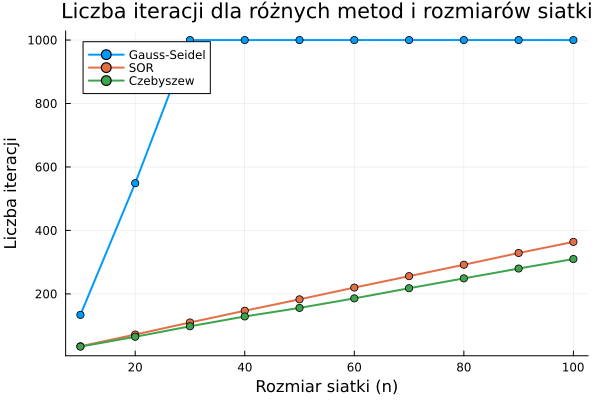

In [62]:
# Zadanie 2 - dla ustalonego progu błędu porównaj liczbę iteracji każdej metody potrzebną do osiągnięcia zbieżności dla coraz większych rozmiarów problemu. 
# Wyniki przedstaw na wykresie
using Roots,Plots,ForwardDiff,LinearAlgebra,Statistics,DataFrames,CSV,Polynomials

# Funkcja do tworzenia siatki początkowej
function create_initial_solution(n)
    T = zeros(n, n)
    hot_temp = 100
    cold_temp = 10
    T[1, :] .= hot_temp
    T[n, :] .= hot_temp
    T[:, 1] .= hot_temp
    T[:, n] .= cold_temp
    return T
end

# Funkcja do tworzenia siatki początkowej
function create_initial_solution(n)
    T = zeros(n, n)
    hot_temp = 100
    cold_temp = 10
    T[1, :] .= hot_temp
    T[n, :] .= hot_temp
    T[:, 1] .= hot_temp
    T[:, n] .= cold_temp
    return T
end

# Testowanie dla różnych rozmiarów siatki
sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
gs_iters = []
sor_iters = []
chebyshev_iters = []

for n in sizes
    T = create_initial_solution(n)
    T_gs = copy(T)
    T_sor = copy(T)
    T_chebyshev = copy(T)
    
    # Każda funkcja zwraca T oraz liczbę iteracji
    T_gs, gs_iter = gauss_seidel_laplace(T_gs)
    T_sor, sor_iter = sor_laplace(T_sor)
    T_chebyshev, chebyshev_iter = chebyshev_laplace(T_chebyshev)
    
    push!(gs_iters, gs_iter)
    push!(sor_iters, sor_iter)
    push!(chebyshev_iters, chebyshev_iter)
end

# Tworzymy DataFrame
df = DataFrame(
    "Rozmiar siatki" => sizes,
    "Gauss-Seidel" => gs_iters,
    "SOR" => sor_iters,
    "Czebyszew" => chebyshev_iters
)

# Wypisanie wyników
println("Wyniki:")
display(df)

# Wykres
plot(
    sizes, [gs_iters, sor_iters, chebyshev_iters], 
    label=["Gauss-Seidel" "SOR" "Czebyszew"],
    xlabel="Rozmiar siatki (n)",
    ylabel="Liczba iteracji",
    title="Liczba iteracji dla różnych metod i rozmiarów siatki",
    linewidth=2,
    markershape=:circle,
    legend=:topleft
)

Czebyszew (T_final): Zbieżność osiągnięta po 672 iteracjach
Gauss-Seidel: Osiągnięto maksymalną liczbę iteracji
SOR: Zbieżność osiągnięta po 543 iteracjach
Czebyszew: Zbieżność osiągnięta po 458 iteracjach


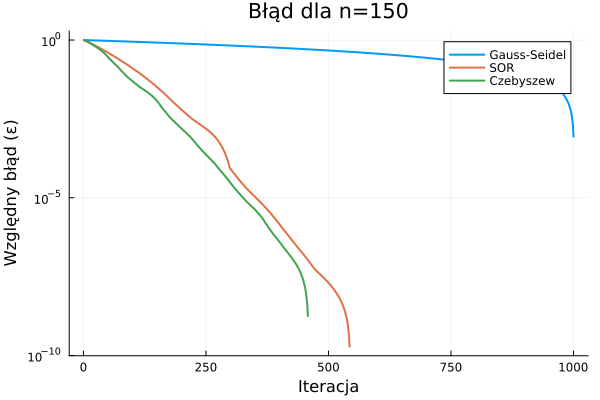

In [63]:
# Zadanie 3 
# Dla rozmiaru powyżej 120 pkt porównaj na jednym wykresie wartość maksymalnego błedu w danej iteracji w stosunku do błedu poczatkowego, 
# w zależności od iteracji, dla każdej z metod. Błąd należy oszacować względem otrzymanego ostatecznego rozwiązania 
# np. pod warunkiem osiągnięcia zbieżności.

function chebyshev_laplace_for_final(T; maxiter=1000, tol=1e-10)
    n = size(T, 1)
    p = cos(pi/n)
    omega = 1.0
    
    for iter in 1:maxiter
        delta = 0.0
        for j in 2:n-1
            for i in 2:n-1
                if (i + j) % 2 == 1
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end
        for j in 2:n-1
            for i in 2:n-1
                if (i + j) % 2 == 0
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end
        if iter == 1
            omega = 1 / (1 - p^2 / 2)
        else
            omega = 1 / (1 - omega * p^2 / 4)
        end
        if delta < tol
            println("Czebyszew (T_final): Zbieżność osiągnięta po $iter iteracjach")
            return T, iter
        end
    end
    println("Czebyszew (T_final): Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter
end

# Metoda Gaussa-Seidla z obliczaniem błędu względem T_final
function gauss_seidel_laplace_error(T, T_final; maxiter=1000, tol=1e-6)
    n = size(T, 1)
    errors = Float64[]
    for iter in 1:maxiter
        delta = 0.0
        for j in 2:n-1
            for i in 2:n-1
                temp = T[i, j]
                T[i, j] = 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                delta = max(delta, abs(T[i, j] - temp))
            end
        end
        # Oblicz błąd względem T_final
        push!(errors, maximum(abs.(T - T_final)))
        if delta < tol
            println("Gauss-Seidel: Zbieżność osiągnięta po $iter iteracjach")
            return T, iter, errors
        end
    end
    println("Gauss-Seidel: Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter, errors
end

# Metoda SOR z obliczaniem błędu względem T_final
function sor_laplace_error(T, T_final; maxiter=1000, tol=1e-6)
    n = size(T, 1)
    errors = Float64[]
    omega = 2 / (1 + sin(pi/n))
    for iter in 1:maxiter
        delta = 0.0
        for j in 2:n-1
            for i in 2:n-1
                temp = T[i, j]
                gs_update = 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                T[i, j] = temp + omega * (gs_update - temp)
                delta = max(delta, abs(T[i, j] - temp))
            end
        end
        push!(errors, maximum(abs.(T - T_final)))
        if delta < tol
            println("SOR: Zbieżność osiągnięta po $iter iteracjach")
            return T, iter, errors
        end
    end
    println("SOR: Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter, errors
end

# Metoda Czebyszewa z obliczaniem błędu względem T_final
function chebyshev_laplace_error(T, T_final; maxiter=1000, tol=1e-6)
    n = size(T, 1)
    errors = Float64[]
    p = cos(pi/n)
    omega = 1.0
    for iter in 1:maxiter
        delta = 0.0
        for j in 2:n-1
            for i in 2:n-1
                if (i + j) % 2 == 1
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end
        for j in 2:n-1
            for i in 2:n-1
                if (i + j) % 2 == 0
                    old_val = T[i, j]
                    T[i, j] = (1 - omega) * T[i, j] + omega * 0.25 * (T[i-1, j] + T[i+1, j] + T[i, j-1] + T[i, j+1])
                    delta = max(delta, abs(T[i, j] - old_val))
                end
            end
        end
        if iter == 1
            omega = 1 / (1 - p^2 / 2)
        else
            omega = 1 / (1 - omega * p^2 / 4)
        end
        push!(errors, maximum(abs.(T - T_final)))
        if delta < tol
            println("Czebyszew: Zbieżność osiągnięta po $iter iteracjach")
            return T, iter, errors
        end
    end
    println("Czebyszew: Osiągnięto maksymalną liczbę iteracji")
    return T, maxiter, errors
end

# Ustawienia i obliczenia
n = 150
T = create_initial_solution(n)

# Oblicz ostateczne rozwiązanie
T_final, _ = chebyshev_laplace_for_final(copy(T))

# Testowanie metod
T_gs, iter_gs, errors_gs = gauss_seidel_laplace_error(copy(T), T_final)
T_sor, iter_sor, errors_sor = sor_laplace_error(copy(T), T_final)
T_cheb, iter_cheb, errors_cheb = chebyshev_laplace_error(copy(T), T_final)

# Oblicz epsilon(iter)
epsilon_gs = [sum(errors_gs[i:end]) / sum(errors_gs) for i in 1:iter_gs]
epsilon_sor = [sum(errors_sor[i:end]) / sum(errors_sor) for i in 1:iter_sor]
epsilon_cheb = [sum(errors_cheb[i:end]) / sum(errors_cheb) for i in 1:iter_cheb]

# Wykres
plot(1:iter_gs, epsilon_gs, label="Gauss-Seidel", xlabel="Iteracja", ylabel="Względny błąd (ε)", yscale=:log10, linewidth=2)
plot!(1:iter_sor, epsilon_sor, label="SOR", linewidth=2)
plot!(1:iter_cheb, epsilon_cheb, label="Czebyszew", linewidth=2, title="Błąd dla n=150", legend=:topright)

SOR: Zbieżność osiągnięta po 149 iteracjach


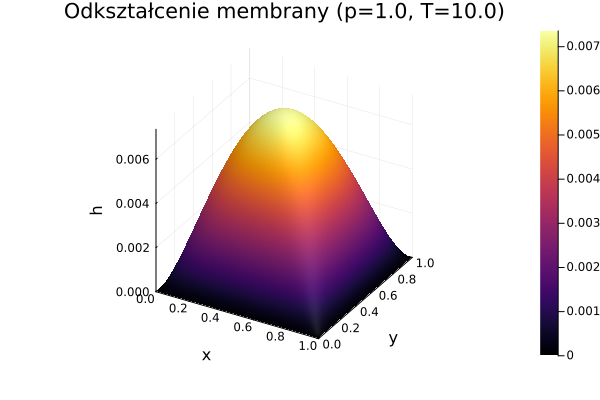

In [65]:
# Zadanie 4 
# Membrana w kształcie kwadratu jest równomiernie obciążona. Membrana znajduje sie w stanie statycznym, a jej brzeg jest sztywno zamocowany i nieodkształcony.
# Za pomocą wybranej metody poznanej na tym laboratorium należy obliczyc odkształcenie membrany od poziomu, zakładając ze spełnia ono równanie Poissona:
# gdzie mamy ustalone parametry:
# p - cisnienie wywierane na membrane.
# T - napiecie membrany
# Poza demonstarcją wartości liczbowych, należy użyć wybranej przez siebie metody wizualizacji wyników.

# Parametry
n = 100              # Rozmiar siatki (n x n)
p = 1.0             # Ciśnienie
T = 10.0             # Napięcie
maxiter = 1000      # Maksymalna liczba iteracji
tol = 1e-6          # Tolerancja zbieżności

# Funkcja rozwiązująca równanie Poissona metodą SOR
function sor_poisson(n, p, T; maxiter=1000, tol=1e-6)
    h = zeros(n, n)  
    dx = 1.0 / (n - 1)
    omega = 2 / (1 + sin(pi/n))  # Optymalny parametr omega dla SOR
    rhs = p / T * dx^2

    for iter in 1:maxiter
        delta = 0.0
        for j in 2:n-1
            for i in 2:n-1
                temp = h[i, j]
                gs_update = 0.25 * (h[i-1, j] + h[i+1, j] + h[i, j-1] + h[i, j+1] + rhs)
                h[i, j] = temp + omega * (gs_update - temp)
                delta = max(delta, abs(h[i, j] - temp))
            end
        end
        if delta < tol
            println("SOR: Zbieżność osiągnięta po $iter iteracjach")
            return h, iter
        end
    end
    println("SOR: Osiągnięto maksymalną liczbę iteracji")
    return h, maxiter
end

# Obliczenie odkształcenia
h, iter = sor_poisson(n, p, T)

# Wizualizacja wyników
x = range(0, 1, length=n)
y = range(0, 1, length=n)
surface(x, y, h, title="Odkształcenie membrany (p=$p, T=$T)", xlabel="x", ylabel="y ", zlabel="h")